In [2]:
import pandas as pd
import glob
import json
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

<Axes: title={'center': 'Polarization Over Time'}, xlabel='Datetime', ylabel='Polarization'>

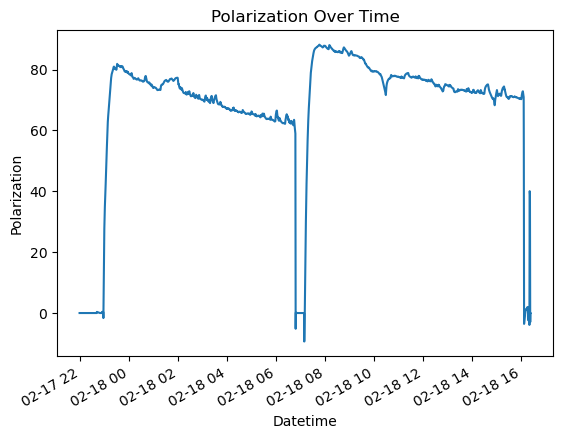

In [3]:
with open("event_json/2009-02-18_16h23m46s.json","r") as eventfile:
    df = pd.read_json(eventfile, lines=True)
df['stop_time'] = pd.to_datetime(df['stop_time'])
df.set_index('stop_time', inplace=True)

# Plot the polarization over time
df['pol'].plot(title='Polarization Over Time',
                      xlabel='Datetime',
                      ylabel='Polarization')

In [4]:
i = 100
phase = np.array(df.iloc[i]['phase'], dtype=float)
freq_list = np.linspace((df['cent_freq']-df['mod_freq'])/1e+6, (df['cent_freq']+df['mod_freq'])/1e+6, 500)

In [5]:
df.head()

,area,cc,pol,cent_freq,mod_freq,gain,sweeps,steps,qmeter_num,bath_temp,uwave_freq,phase
stop_time,,,,,,,,,,,,
2009-02-17 21:58:38,0.0,0.0,0.0,0,0,0.0,0,0,0,1.259,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 21:59:08,0.0,0.0,0.0,0,0,0.0,0,0,0,1.259,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 21:59:38,0.0,0.0,0.0,0,0,0.0,0,0,0,1.259,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 22:07:08,0.0,0.0,0.0,0,0,0.0,0,0,0,-1.000,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2009-02-17 22:08:03,0.0,0.0,0.0,0,0,0.0,0,0,0,1.288,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


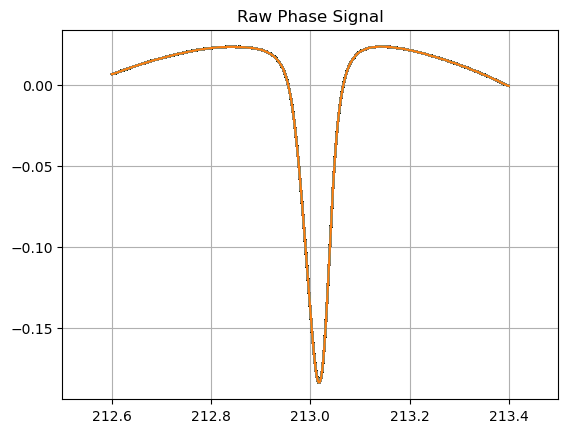

In [6]:
plt.plot(freq_list, phase)
plt.xlim(212.5, 213.5)
plt.title('Raw Phase Signal')
plt.grid()
plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

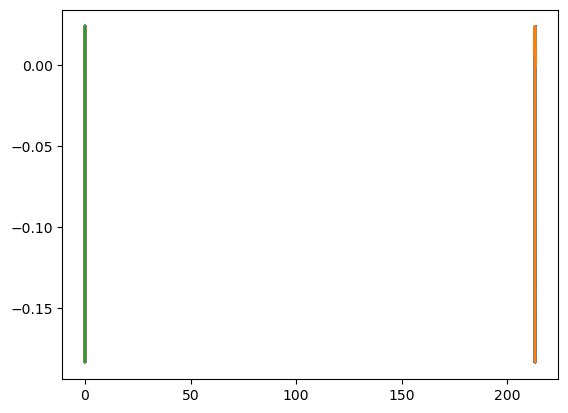

In [ ]:
wings = [0.01, .25, .8, .99]  
bounds = [x * len(phase) for x in wings]
data = [z for x, z in enumerate(zip(freq_list, phase)) if (bounds[0] < x < bounds[1] or bounds[2] < x < bounds[3])]
# There's surely a better way to do this with NumPy, but I was initially working with Python lists

X = np.array([x for x, y in data])   
Y = np.array([y for x, y in data])

plt.plot(freq_list, phase)
for x in X:
    plt.axvline(x, color='green', alpha=0.05,)
plt.plot(X, Y)
plt.title('Baseline Subtracted and Fit Candidate')
plt.grid()
plt.show()